Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

Load Dataset

In [ ]:
df = pd.read_csv("data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Data Cleaning

In [ ]:
df = df.drop(['id', 'Unnamed: 32'], axis=1)

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

Data Understanding

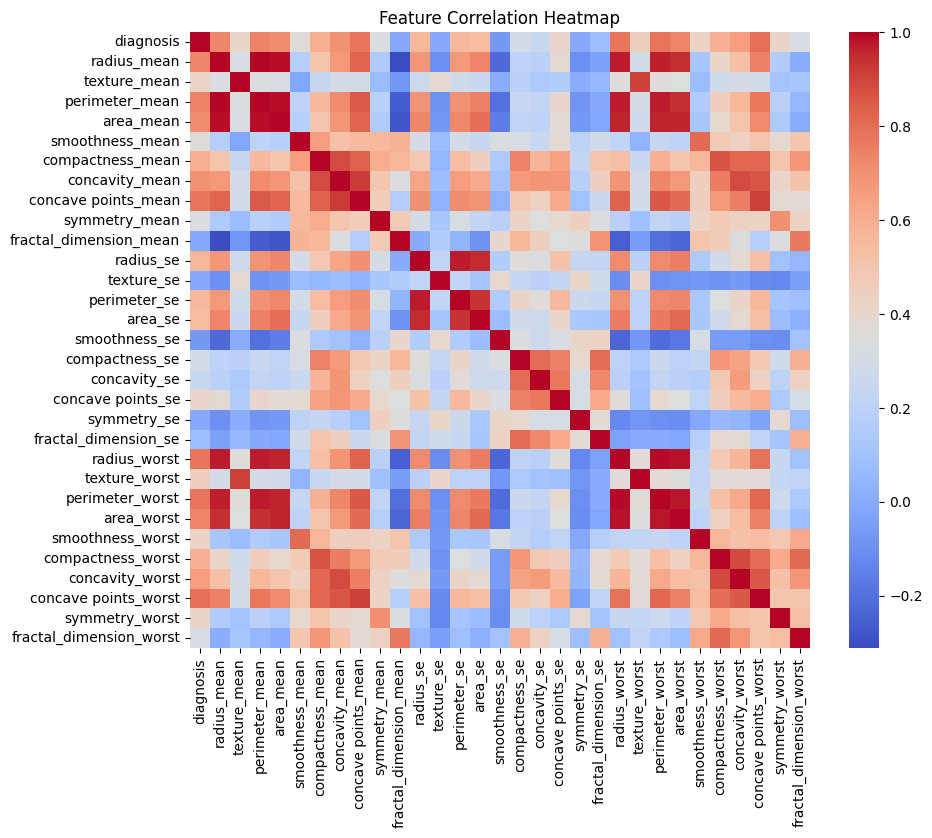

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Split Features & Target

In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Build IMPROVED Neural Network

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Add Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5)

Train Model

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.9902 - loss: 0.0429 - val_accuracy: 1.0000 - val_loss: 0.0439
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9927 - loss: 0.0389 - val_accuracy: 1.0000 - val_loss: 0.0433
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9878 - loss: 0.0386 - val_accuracy: 0.9783 - val_loss: 0.0449
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9878 - loss: 0.0451 - val_accuracy: 0.9783 - val_loss: 0.0459
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9878 - loss: 0.0394 - val_accuracy: 0.9783 - val_loss: 0.0468
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9902 - loss: 0.0345 - val_accuracy: 0.9783 - val_loss: 0.0457
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9853 - loss: 0.0500 - val_accuracy: 0.9783 - val_loss: 0.0461


Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9912 - loss: 0.0562
Accuracy: 0.9912280440330505


Predictions

In [ ]:
y_pred = (model.predict(X_test) > 0.5)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[71  0]
 [ 1 42]]


Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



Accuracy Graph

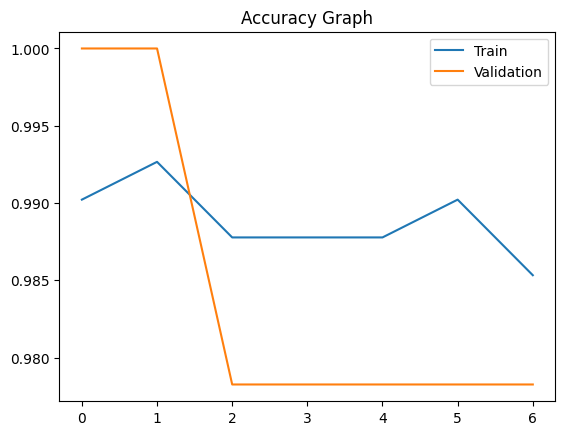

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Graph")
plt.legend(['Train', 'Validation'])
plt.show()

Loss Graph

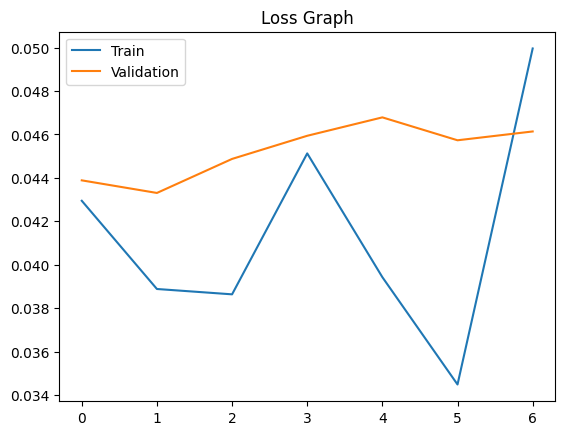

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Graph")
plt.legend(['Train', 'Validation'])
plt.show()